# 🏥 Healthcare Resource Utilization Dashboard
### Patient Trends • Billing Analysis • Outlier Detection • Insights Report

**Objective:** Analyze patient trends, billing patterns, and treatment outliers to support better healthcare decision-making.

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['font.family'] = 'DejaVu Sans'

# 🏥 Healthcare Resource Utilization Dashboard
### Patient Trends • Billing Analysis • Outlier Detection • Insights Report

**Objective:**  
To analyze hospital patient records, identify disease trends, billing anomalies, and resource utilization patterns for better healthcare decision-making.

Importing Data and CSV File

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["font.family"] = "DejaVu Sans"

df = pd.read_csv("healthcare_dataset.csv")
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## 📋 Dataset Overview
This dataset contains patient-level healthcare records including:
- Age
- Gender
- Medical Condition
- Admission Type
- Billing Amount
- Stay Duration

In [19]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [20]:
df.info()
df.describe()
print("Rows, Columns:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

Data Cleaning - remove duplicates

In [21]:
df = df.drop_duplicates()

Convert dates

In [22]:
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"])

Create stay duration

In [23]:
df["Stay_Days"] = (
    df["Discharge Date"] - df["Date of Admission"]
).dt.days

# KPI METRICS CREATION.


In [24]:
total_patients = df.shape[0]
avg_bill = df["Billing Amount"].mean()
avg_stay = df["Stay_Days"].mean()
most_common = df["Medical Condition"].mode()[0]

print("📌 Total Patients:", total_patients)
print("💰 Avg Billing: ₹", round(avg_bill,2))
print("🛏 Avg Stay Days:", round(avg_stay,2))
print("🩺 Most Common Condition:", most_common)

📌 Total Patients: 54966
💰 Avg Billing: ₹ 25544.31
🛏 Avg Stay Days: 15.5
🩺 Most Common Condition: Arthritis


# Visualisations

## 🩺 Disease Trend Analysis
Which conditions are most frequent?

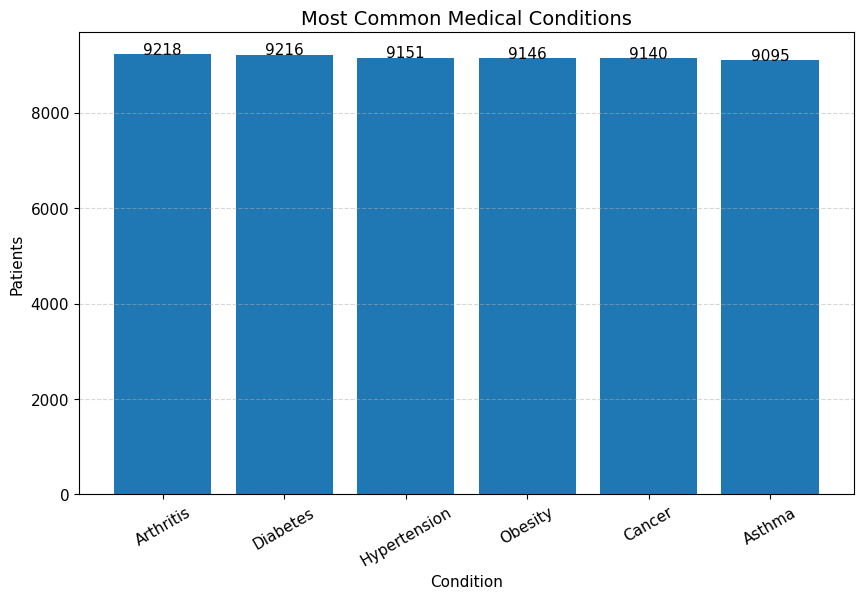

In [25]:
condition_counts = df["Medical Condition"].value_counts()

plt.figure(figsize=(10,6))
bars = plt.bar(condition_counts.index, condition_counts.values)

plt.title("Most Common Medical Conditions")
plt.xlabel("Condition")
plt.ylabel("Patients")
plt.xticks(rotation=30)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+1,
        int(bar.get_height()),
        ha='center'
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## 💰 Billing & Revenue Insights
Average billing cost by disease

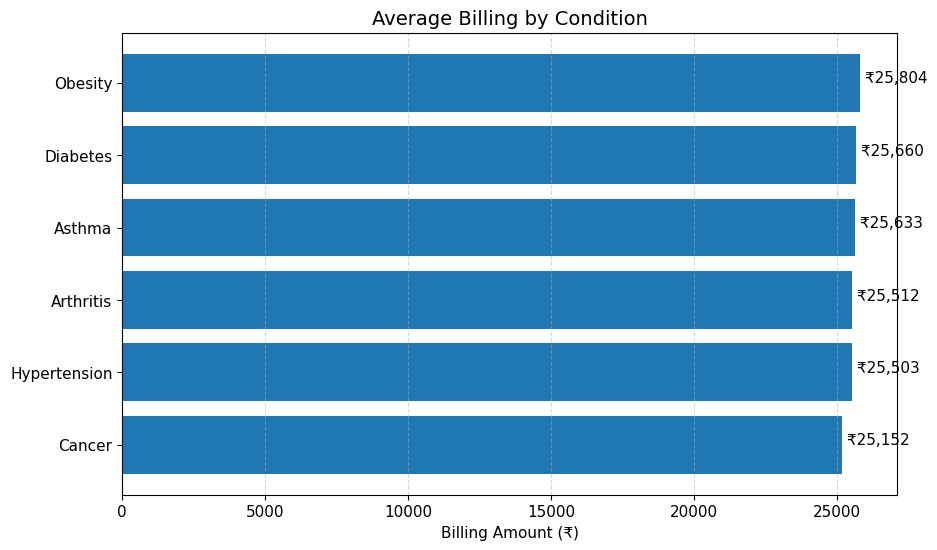

In [26]:
avg_bill = (
    df.groupby("Medical Condition")["Billing Amount"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,6))
bars = plt.barh(avg_bill.index, avg_bill.values)

plt.title("Average Billing by Condition")
plt.xlabel("Billing Amount (₹)")

for i, v in enumerate(avg_bill.values):
    plt.text(v, i, f" ₹{v:,.0f}")

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

## 👩‍⚕️ Patient Demographics
Understanding age distribution and patient profile

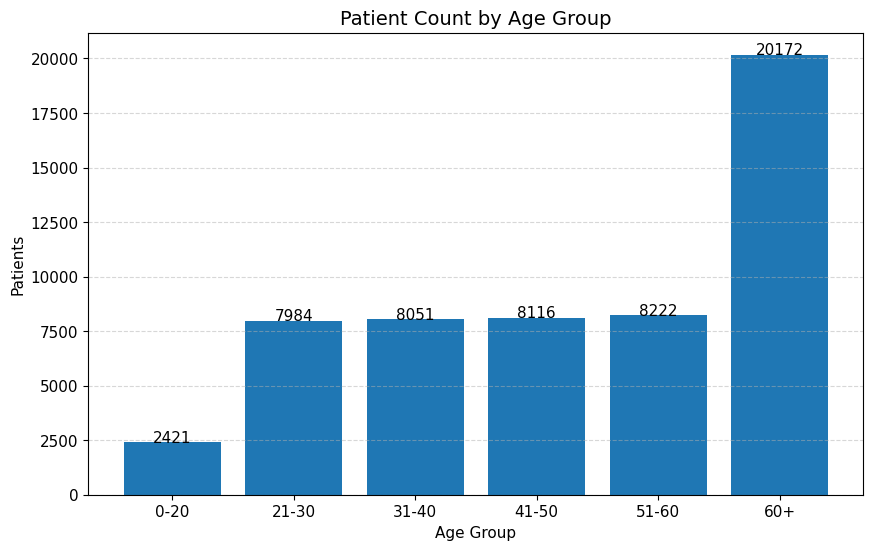

In [27]:
bins = [0,20,30,40,50,60,100]
labels = ["0-20","21-30","31-40","41-50","51-60","60+"]

df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

age_counts = df["Age_Group"].value_counts().sort_index()

plt.figure(figsize=(10,6))
bars = plt.bar(age_counts.index, age_counts.values)

plt.title("Patient Count by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Patients")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+1,
        int(bar.get_height()),
        ha='center'
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## 🛏 Average Hospital Stay by Medical Condition

This section analyzes the **average number of days patients stay in the hospital** for each medical condition.  
It helps identify:

- conditions that require **longer treatment duration**
- possible **resource-intensive departments**
- diseases associated with **extended recovery periods**

Longer stay durations may indicate:
- severe illness
- post-surgery recovery
- intensive care requirements
- chronic disease management

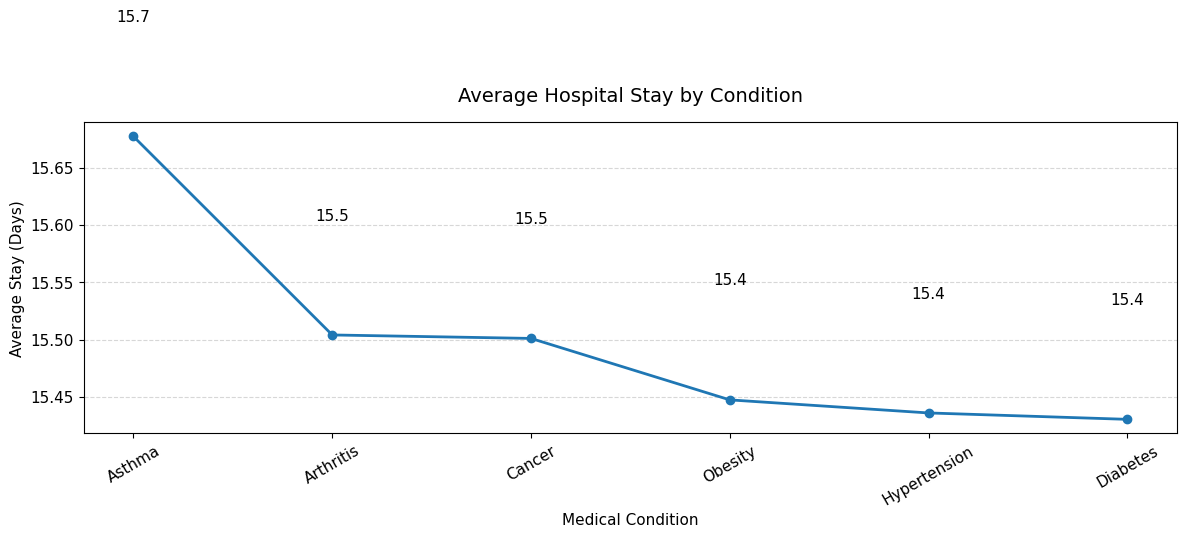

In [28]:
# Average stay duration by condition
stay = (
    df.groupby("Medical Condition")["Stay_Days"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))

line = ax.plot(
    stay.index,
    stay.values,
    marker='o',
    linewidth=2
)

ax.set_title("Average Hospital Stay by Condition", pad=15)
ax.set_xlabel("Medical Condition")
ax.set_ylabel("Average Stay (Days)")

plt.xticks(rotation=30)

# Add value labels above each point
for x, y in zip(stay.index, stay.values):
    ax.text(
        x,
        y + 0.1,
        f"{y:.1f}",
        ha='center'
    )

ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 🚨 Billing Outlier Detection
Identify unusually expensive treatment cases

<Figure size 1200x600 with 0 Axes>

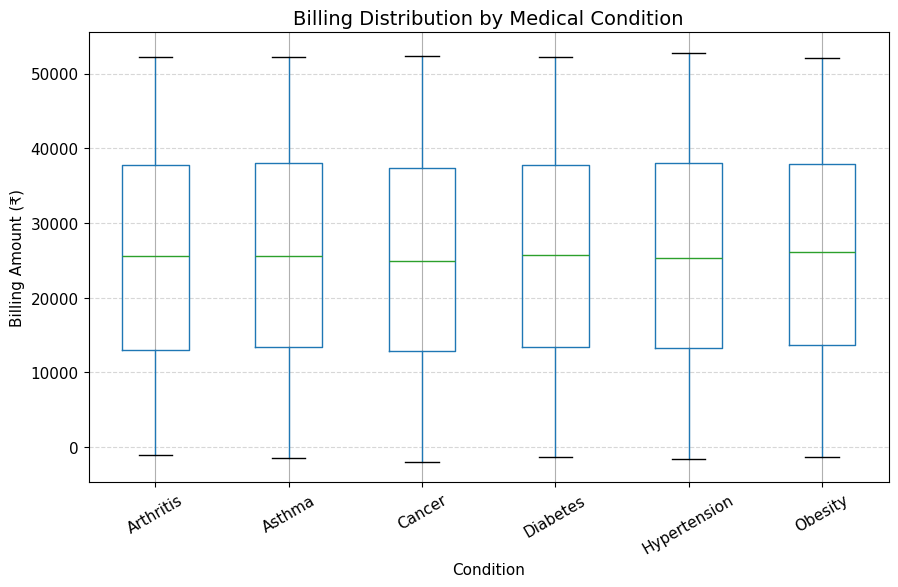

In [29]:
plt.figure(figsize=(12,6))

df.boxplot(column="Billing Amount", by="Medical Condition")

plt.title("Billing Distribution by Medical Condition")
plt.suptitle("")
plt.xlabel("Condition")
plt.ylabel("Billing Amount (₹)")
plt.xticks(rotation=30)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## 📌 Key Insights

1. Patient Demographics Skew Toward Elderly Population

The dataset shows a significant concentration of patients in the 60+ age group, making it the largest segment by a wide margin. This indicates that the hospital primarily caters to an aging population, which typically requires more frequent and complex medical care.

2. Even Distribution of Medical Conditions

The frequency of major medical conditions such as Arthritis, Diabetes, Hypertension, Obesity, and Cancer is relatively uniform across the dataset. No single condition overwhelmingly dominates patient records.

This suggests that the hospital operates as a multi-specialty facility, handling a diverse range of chronic illnesses rather than focusing on a specific disease category.

3. Minimal Variation in Billing Across Conditions

The analysis reveals that average billing amounts remain relatively consistent across different medical conditions, with only minor variations.

This indicates a standardized or package-based pricing model, where treatment costs are not significantly influenced by the type or complexity of the condition.

4. Consistent Length of Stay Across Patients

The average hospital stay is approximately 15 days, with most patients falling within a moderate range of hospitalization duration.

This reflects a pattern of extended care, likely associated with chronic disease management and recovery monitoring.

5. Lack of Correlation Between Billing and Length of Stay

A key finding from the analysis is the absence of a meaningful relationship between billing amount and length of stay.

Despite longer hospitalizations, billing does not increase proportionally, suggesting that:

pricing is not time-dependent
resource utilization may not be fully reflected in costs
6. Balanced Distribution of Test Results

Test outcomes (Normal, Abnormal, Inconclusive) are evenly distributed across the dataset.

This may indicate broad diagnostic coverage; however, it could also point to variability in diagnostic precision or testing strategies, requiring further evaluation.

7. Gender Distribution is Nearly Equal

The dataset shows a balanced representation of male and female patients, indicating no significant gender bias in hospital admissions or treatment access.

## 💡 Recommendations

1. Strengthen Geriatric Care Services

Given the dominance of the elderly patient population, the hospital should invest in:

specialized geriatric units
age-specific treatment protocols
long-term care management programs
2. Implement Condition-Based Pricing Models

The current uniform billing structure should be re-evaluated. Introducing condition-specific or complexity-based pricing can:

improve cost transparency
better reflect resource utilization
enhance financial sustainability
3. Optimize Length of Stay Management

Although hospital stays are moderately long, they do not influence billing. The hospital should:

streamline discharge processes
improve treatment efficiency
reduce unnecessary prolonged stays

This will help improve bed availability and operational efficiency.

4. Revise Billing Strategy to Reflect Resource Usage

The lack of correlation between billing and length of stay suggests inefficiencies in pricing.

A hybrid billing model (fixed + variable components) is recommended to:

align costs with actual care provided
ensure fair pricing
5. Develop Specialized Care Pathways

Since medical conditions are evenly distributed, the hospital should:

establish dedicated treatment pathways
improve departmental specialization
enhance patient outcomes through targeted care
6. Improve Diagnostic Effectiveness

The equal distribution of test results warrants further investigation. The hospital should:

evaluate diagnostic accuracy
standardize testing protocols
ensure appropriate use of medical tests
7. Promote Preventive Healthcare Initiatives

With chronic diseases prevalent among elderly patients, the hospital should:

introduce preventive screening programs
encourage early intervention strategies
promote lifestyle management awareness